In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
from sklearn.preprocessing import MinMaxScaler

In [3]:
data = pd.read_csv('stock.csv')
print(data.head())

         Date         Open         High          Low        Close  \
0  01-04-2020  1122.000000  1129.689941  1097.449951  1105.619995   
1  02-04-2020  1098.260010  1126.859985  1096.400024  1120.839966   
2  03-04-2020  1119.015015  1123.540039  1079.810059  1097.880005   
3  06-04-2020  1138.000000  1194.660034  1130.939941  1186.920044   
4  07-04-2020  1221.000000  1225.000000  1182.229980  1186.510010   

     Adj Close   Volume  
0  1105.619995  2343100  
1  1120.839966  1964900  
2  1097.880005  2313400  
3  1186.920044  2664700  
4  1186.510010  2387300  


In [4]:
prices = data['Close'].values.reshape(-1,1)

In [5]:
#Normalize
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

In [ ]:
def create_sequence(data,window_size):
    X=[]
    y=[]

    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X),np.array(y)

window_size=5

X,y = create_sequence(prices_scaled,window_size)

In [7]:
X = X.reshape(X.shape[0],X.shape[1],1)
X.shape

(122, 5, 1)

In [8]:
split = int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [9]:
model = Sequential([
    SimpleRNN(50,activation='tanh',input_shape=(window_size,1)),
    Dense(1)
])

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',loss='mse')
model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.1304 - val_loss: 0.0182
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0212 - val_loss: 0.0797
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0389 - val_loss: 0.0227
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0074 - val_loss: 0.0232
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0128 - val_loss: 0.0276
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0112 - val_loss: 0.0157
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0052 - val_loss: 0.0155
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0058 - val_loss: 0.0189
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0078 - val_loss: 0.0188
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0070 - val_loss: 0.0145
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0045 - val_loss: 0.0139
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0051 - val_loss: 0.0136
E

In [11]:
predictions=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [12]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

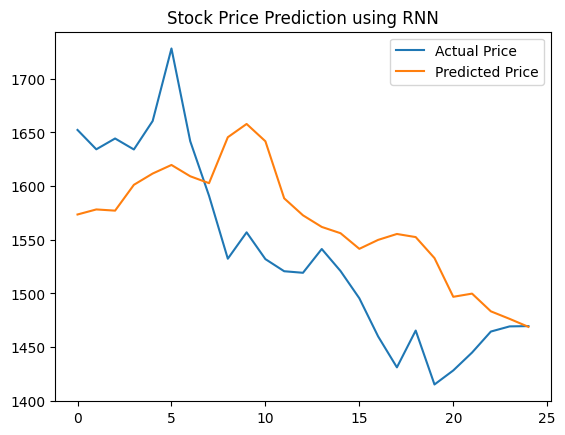

In [13]:
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction using RNN")
plt.show()

# Project 2

In [21]:
stock_data = [
    {"date": "2024-01-01", "open_price": 100, "high_price": 105, "low_price": 98, "close_price": 103, "volume": 1200},
    {"date": "2024-01-02", "open_price": 103, "high_price": 108, "low_price": 101, "close_price": 106, "volume": 1350},
    {"date": "2024-01-03", "open_price": 106, "high_price": 110, "low_price": 104, "close_price": 108, "volume": 1280},
    {"date": "2024-01-04", "open_price": 108, "high_price": 112, "low_price": 105, "close_price": 107, "volume": 1400},
    {"date": "2024-01-05", "open_price": 107, "high_price": 111, "low_price": 103, "close_price": 109, "volume": 1500},
    {"date": "2024-01-06", "open_price": 109, "high_price": 115, "low_price": 108, "close_price": 113, "volume": 1600},
    {"date": "2024-01-07", "open_price": 113, "high_price": 118, "low_price": 111, "close_price": 116, "volume": 1550},
    {"date": "2024-01-08", "open_price": 116, "high_price": 120, "low_price": 114, "close_price": 119, "volume": 1700},
    {"date": "2024-01-09", "open_price": 119, "high_price": 123, "low_price": 117, "close_price": 121, "volume": 1650},
    {"date": "2024-01-10", "open_price": 121, "high_price": 125, "low_price": 119, "close_price": 124, "volume": 1800},

    {"date": "2024-01-11", "open_price": 124, "high_price": 128, "low_price": 122, "close_price": 126, "volume": 1750},
    {"date": "2024-01-12", "open_price": 126, "high_price": 130, "low_price": 123, "close_price": 125, "volume": 1850},
    {"date": "2024-01-13", "open_price": 125, "high_price": 129, "low_price": 121, "close_price": 127, "volume": 1900},
    {"date": "2024-01-14", "open_price": 127, "high_price": 132, "low_price": 125, "close_price": 131, "volume": 2000},
    {"date": "2024-01-15", "open_price": 131, "high_price": 136, "low_price": 129, "close_price": 134, "volume": 2100},
    {"date": "2024-01-16", "open_price": 134, "high_price": 138, "low_price": 132, "close_price": 137, "volume": 2050},
    {"date": "2024-01-17", "open_price": 137, "high_price": 140, "low_price": 134, "close_price": 136, "volume": 2150},
    {"date": "2024-01-18", "open_price": 136, "high_price": 141, "low_price": 133, "close_price": 139, "volume": 2200},
    {"date": "2024-01-19", "open_price": 139, "high_price": 145, "low_price": 137, "close_price": 143, "volume": 2300},
    {"date": "2024-01-20", "open_price": 143, "high_price": 148, "low_price": 140, "close_price": 146, "volume": 2400},

    {"date": "2024-01-21", "open_price": 146, "high_price": 150, "low_price": 143, "close_price": 149, "volume": 2350},
    {"date": "2024-01-22", "open_price": 149, "high_price": 153, "low_price": 146, "close_price": 151, "volume": 2450},
    {"date": "2024-01-23", "open_price": 151, "high_price": 156, "low_price": 148, "close_price": 154, "volume": 2500},
    {"date": "2024-01-24", "open_price": 154, "high_price": 159, "low_price": 151, "close_price": 157, "volume": 2600},
    {"date": "2024-01-25", "open_price": 157, "high_price": 162, "low_price": 154, "close_price": 160, "volume": 2700},
    {"date": "2024-01-26", "open_price": 160, "high_price": 164, "low_price": 157, "close_price": 162, "volume": 2650},
    {"date": "2024-01-27", "open_price": 162, "high_price": 166, "low_price": 159, "close_price": 161, "volume": 2750},
    {"date": "2024-01-28", "open_price": 161, "high_price": 168, "low_price": 160, "close_price": 165, "volume": 2800},
    {"date": "2024-01-29", "open_price": 165, "high_price": 170, "low_price": 162, "close_price": 168, "volume": 2900},
    {"date": "2024-01-30", "open_price": 168, "high_price": 173, "low_price": 165, "close_price": 171, "volume": 3000},

    {"date": "2024-01-31", "open_price": 171, "high_price": 176, "low_price": 168, "close_price": 174, "volume": 3100},
    {"date": "2024-02-01", "open_price": 174, "high_price": 179, "low_price": 170, "close_price": 173, "volume": 3050},
    {"date": "2024-02-02", "open_price": 173, "high_price": 178, "low_price": 169, "close_price": 175, "volume": 3150},
{"date": "2024-02-03", "open_price": 175, "high_price": 181, "low_price": 172, "close_price": 179, "volume": 3200},
    {"date": "2024-02-04", "open_price": 179, "high_price": 184, "low_price": 176, "close_price": 182, "volume": 3300},
    {"date": "2024-02-05", "open_price": 182, "high_price": 186, "low_price": 178, "close_price": 181, "volume": 3250},
    {"date": "2024-02-06", "open_price": 181, "high_price": 187, "low_price": 179, "close_price": 185, "volume": 3350},
    {"date": "2024-02-07", "open_price": 185, "high_price": 190, "low_price": 182, "close_price": 188, "volume": 3400},
    {"date": "2024-02-08", "open_price": 188, "high_price": 193, "low_price": 185, "close_price": 191, "volume": 3500},
    {"date": "2024-02-09", "open_price": 191, "high_price": 195, "low_price": 187, "close_price": 190, "volume": 3450},

    {"date": "2024-02-10", "open_price": 190, "high_price": 196, "low_price": 188, "close_price": 194, "volume": 3550},
    {"date": "2024-02-11", "open_price": 194, "high_price": 199, "low_price": 191, "close_price": 197, "volume": 3600},
    {"date": "2024-02-12", "open_price": 197, "high_price": 202, "low_price": 194, "close_price": 200, "volume": 3700},
    {"date": "2024-02-13", "open_price": 200, "high_price": 205, "low_price": 196, "close_price": 199, "volume": 3650},
    {"date": "2024-02-14", "open_price": 199, "high_price": 204, "low_price": 195, "close_price": 201, "volume": 3750},
    {"date": "2024-02-15", "open_price": 201, "high_price": 207, "low_price": 198, "close_price": 205, "volume": 3800},
    {"date": "2024-02-16", "open_price": 205, "high_price": 210, "low_price": 202, "close_price": 208, "volume": 3900},
    {"date": "2024-02-17", "open_price": 208, "high_price": 213, "low_price": 204, "close_price": 207, "volume": 3850},
    {"date": "2024-02-18", "open_price": 207, "high_price": 214, "low_price": 205, "close_price": 211, "volume": 3950},
    {"date": "2024-02-19", "open_price": 211, "high_price": 216, "low_price": 208, "close_price": 214, "volume": 4000},
]

In [37]:
import numpy as np
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN,Dense 
import matplotlib.pyplot as plt

In [38]:
df = pd.DataFrame(stock_data)

In [39]:
features = ['open_price','high_price','low_price','close_price','volume']
data = df[features].values

In [40]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [41]:
window_size=3
X=[]
y=[]

for i in range(len(data_scaled)-window_size):
    X.append(data_scaled[i:i+window_size])
    y.append(data_scaled[i+window_size])
X = np.array(X)
y = np.array(y)


In [42]:
split = int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [43]:
model = Sequential([
    SimpleRNN(50,activation='tanh',input_shape=(window_size,5)),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
model.summary()

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,851 (11.14 KB)

 Trainable params: 2,851 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=4,
    verbose=1
)

Epoch 1/100


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0205
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1332e-04 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.3638e-04 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2945e-04 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3011e-04
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2247e-04 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9412e-04 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6527e-04 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3662e-04 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3818e-04 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2147e-04 
Epoch 15/100
10/10 ━━━━━━━━━━━━

In [45]:
pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


In [46]:
pred

array([[0.8284151 ],
       [0.8487978 ],
       [0.8730655 ],
       [0.8905237 ],
       [0.8962525 ],
       [0.91090393],
       [0.93624514],
       [0.9504333 ],
       [0.95141506],
       [0.97299916]], dtype=float32)

In [48]:
# predicted values
dummy_pred = np.zeros((len(pred), 5))
dummy_pred[:, 3] = pred[:, 0]

predicted_close = scaler.inverse_transform(dummy_pred)[:, 3]



In [50]:
print(y_test.shape)

(10, 5)


In [51]:
# actual values
dummy_actual = np.zeros((len(y_test), 5))
dummy_actual[:, :] = y_test

actual_close = scaler.inverse_transform(dummy_actual)[:, 3]

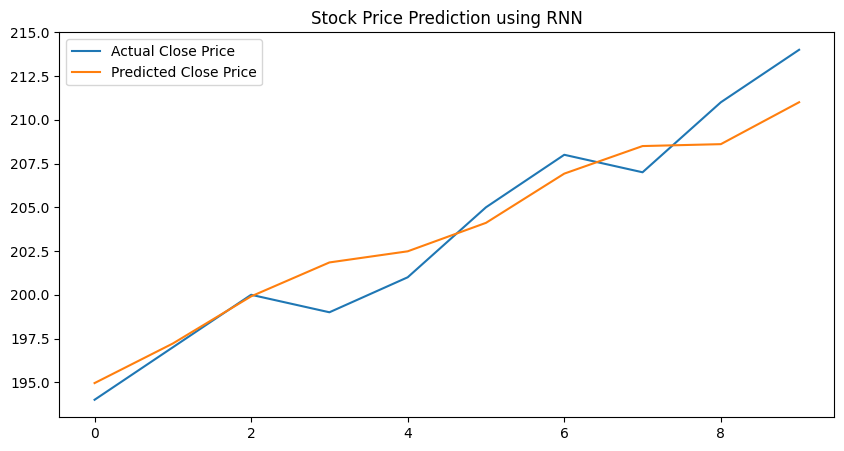

In [52]:
plt.figure(figsize=(10,5))

plt.plot(actual_close, label="Actual Close Price")
plt.plot(predicted_close, label="Predicted Close Price")

plt.legend()
plt.title("Stock Price Prediction using RNN")
plt.show()

# Project 3

In [1]:
stock_data = [
    {"date": "2024-01-01", "open_price": 100, "high_price": 105, "low_price": 98, "close_price": 103, "volume": 1200},
    {"date": "2024-01-02", "open_price": 103, "high_price": 108, "low_price": 101, "close_price": 106, "volume": 1350},
    {"date": "2024-01-03", "open_price": 106, "high_price": 110, "low_price": 104, "close_price": 108, "volume": 1280},
    {"date": "2024-01-04", "open_price": 108, "high_price": 112, "low_price": 105, "close_price": 107, "volume": 1400},
    {"date": "2024-01-05", "open_price": 107, "high_price": 111, "low_price": 103, "close_price": 109, "volume": 1500},
    {"date": "2024-01-06", "open_price": 109, "high_price": 115, "low_price": 108, "close_price": 113, "volume": 1600},
    {"date": "2024-01-07", "open_price": 113, "high_price": 118, "low_price": 111, "close_price": 116, "volume": 1550},
    {"date": "2024-01-08", "open_price": 116, "high_price": 120, "low_price": 114, "close_price": 119, "volume": 1700},
    {"date": "2024-01-09", "open_price": 119, "high_price": 123, "low_price": 117, "close_price": 121, "volume": 1650},
    {"date": "2024-01-10", "open_price": 121, "high_price": 125, "low_price": 119, "close_price": 124, "volume": 1800},

    {"date": "2024-01-11", "open_price": 124, "high_price": 128, "low_price": 122, "close_price": 126, "volume": 1750},
    {"date": "2024-01-12", "open_price": 126, "high_price": 130, "low_price": 123, "close_price": 125, "volume": 1850},
    {"date": "2024-01-13", "open_price": 125, "high_price": 129, "low_price": 121, "close_price": 127, "volume": 1900},
    {"date": "2024-01-14", "open_price": 127, "high_price": 132, "low_price": 125, "close_price": 131, "volume": 2000},
    {"date": "2024-01-15", "open_price": 131, "high_price": 136, "low_price": 129, "close_price": 134, "volume": 2100},
    {"date": "2024-01-16", "open_price": 134, "high_price": 138, "low_price": 132, "close_price": 137, "volume": 2050},
    {"date": "2024-01-17", "open_price": 137, "high_price": 140, "low_price": 134, "close_price": 136, "volume": 2150},
    {"date": "2024-01-18", "open_price": 136, "high_price": 141, "low_price": 133, "close_price": 139, "volume": 2200},
    {"date": "2024-01-19", "open_price": 139, "high_price": 145, "low_price": 137, "close_price": 143, "volume": 2300},
    {"date": "2024-01-20", "open_price": 143, "high_price": 148, "low_price": 140, "close_price": 146, "volume": 2400},

    {"date": "2024-01-21", "open_price": 146, "high_price": 150, "low_price": 143, "close_price": 149, "volume": 2350},
    {"date": "2024-01-22", "open_price": 149, "high_price": 153, "low_price": 146, "close_price": 151, "volume": 2450},
    {"date": "2024-01-23", "open_price": 151, "high_price": 156, "low_price": 148, "close_price": 154, "volume": 2500},
    {"date": "2024-01-24", "open_price": 154, "high_price": 159, "low_price": 151, "close_price": 157, "volume": 2600},
    {"date": "2024-01-25", "open_price": 157, "high_price": 162, "low_price": 154, "close_price": 160, "volume": 2700},
    {"date": "2024-01-26", "open_price": 160, "high_price": 164, "low_price": 157, "close_price": 162, "volume": 2650},
    {"date": "2024-01-27", "open_price": 162, "high_price": 166, "low_price": 159, "close_price": 161, "volume": 2750},
    {"date": "2024-01-28", "open_price": 161, "high_price": 168, "low_price": 160, "close_price": 165, "volume": 2800},
    {"date": "2024-01-29", "open_price": 165, "high_price": 170, "low_price": 162, "close_price": 168, "volume": 2900},
    {"date": "2024-01-30", "open_price": 168, "high_price": 173, "low_price": 165, "close_price": 171, "volume": 3000},

    {"date": "2024-01-31", "open_price": 171, "high_price": 176, "low_price": 168, "close_price": 174, "volume": 3100},
    {"date": "2024-02-01", "open_price": 174, "high_price": 179, "low_price": 170, "close_price": 173, "volume": 3050},
    {"date": "2024-02-02", "open_price": 173, "high_price": 178, "low_price": 169, "close_price": 175, "volume": 3150},
{"date": "2024-02-03", "open_price": 175, "high_price": 181, "low_price": 172, "close_price": 179, "volume": 3200},
    {"date": "2024-02-04", "open_price": 179, "high_price": 184, "low_price": 176, "close_price": 182, "volume": 3300},
    {"date": "2024-02-05", "open_price": 182, "high_price": 186, "low_price": 178, "close_price": 181, "volume": 3250},
    {"date": "2024-02-06", "open_price": 181, "high_price": 187, "low_price": 179, "close_price": 185, "volume": 3350},
    {"date": "2024-02-07", "open_price": 185, "high_price": 190, "low_price": 182, "close_price": 188, "volume": 3400},
    {"date": "2024-02-08", "open_price": 188, "high_price": 193, "low_price": 185, "close_price": 191, "volume": 3500},
    {"date": "2024-02-09", "open_price": 191, "high_price": 195, "low_price": 187, "close_price": 190, "volume": 3450},

    {"date": "2024-02-10", "open_price": 190, "high_price": 196, "low_price": 188, "close_price": 194, "volume": 3550},
    {"date": "2024-02-11", "open_price": 194, "high_price": 199, "low_price": 191, "close_price": 197, "volume": 3600},
    {"date": "2024-02-12", "open_price": 197, "high_price": 202, "low_price": 194, "close_price": 200, "volume": 3700},
    {"date": "2024-02-13", "open_price": 200, "high_price": 205, "low_price": 196, "close_price": 199, "volume": 3650},
    {"date": "2024-02-14", "open_price": 199, "high_price": 204, "low_price": 195, "close_price": 201, "volume": 3750},
    {"date": "2024-02-15", "open_price": 201, "high_price": 207, "low_price": 198, "close_price": 205, "volume": 3800},
    {"date": "2024-02-16", "open_price": 205, "high_price": 210, "low_price": 202, "close_price": 208, "volume": 3900},
    {"date": "2024-02-17", "open_price": 208, "high_price": 213, "low_price": 204, "close_price": 207, "volume": 3850},
    {"date": "2024-02-18", "open_price": 207, "high_price": 214, "low_price": 205, "close_price": 211, "volume": 3950},
    {"date": "2024-02-19", "open_price": 211, "high_price": 216, "low_price": 208, "close_price": 214, "volume": 4000},
]

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.DataFrame(stock_data)
print(df.head())

         date  open_price  high_price  low_price  close_price  volume
0  2024-01-01         100         105         98          103    1200
1  2024-01-02         103         108        101          106    1350
2  2024-01-03         106         110        104          108    1280
3  2024-01-04         108         112        105          107    1400
4  2024-01-05         107         111        103          109    1500


In [5]:
data = df['close_price'].values.reshape(-1,1)

In [6]:
print(data.shape)

(50, 1)


In [7]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [8]:
time_step = 5
def create_dataset(dataset,time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)
X,y = create_dataset(data_scaled,time_step)

In [9]:
print(X.shape)
print(y.shape)

(45, 5, 1)
(45, 1)


In [10]:
split = int(len(X)*0.8)

X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [11]:
model = Sequential()

model.add(SimpleRNN(32,input_shape=(time_step,1)))
model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(optimizer='adam',loss='mse')

In [16]:
model.fit(X_train,y_train,epochs=50,batch_size=8,validation_data=(X_test,y_test),verbose=1)

Epoch 1/50


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.1024 - val_loss: 0.0883
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0063 - val_loss: 0.0014
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0152 - val_loss: 0.0069
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0105 - val_loss: 0.0018
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0013 - val_loss: 0.0210
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0033 - val_loss: 0.0280
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0029 - val_loss: 0.0140
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.5332e-04 - val_loss: 0.0039
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.0876e-04 - val_loss: 0.0020
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.0214e-04 - val_loss: 0.0040
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.7433e-04 - val_loss: 0.0068
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.3473e-04 - val_loss:

In [18]:
prediction = model.predict(X_test)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


In [19]:
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

In [20]:
last_seq = np.array([201,205,208,207,211]).reshape(-1,1)

In [21]:
last_seq = last_seq.reshape(1,5,1)


In [22]:
next_scaled = model.predict(last_seq,verbose=0)

In [23]:
next_prices = scaler.inverse_transform(next_scaled)
print(next_prices)

[[120.7213]]


# Project 4

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
from sklearn.preprocessing import MinMaxScaler

In [9]:
df = pd.DataFrame(stock_data)

In [10]:
df.head()

,date,open_price,high_price,low_price,close_price,volume
0,2024-01-01,100,105,98,103,1200
1,2024-01-02,103,108,101,106,1350
2,2024-01-03,106,110,104,108,1280
3,2024-01-04,108,112,105,107,1400
4,2024-01-05,107,111,103,109,1500


In [11]:
data = df['close_price'].values.reshape(-1,1)

In [12]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [15]:
def create_dataset(dataset,time_step):
    X=[]
    y=[]
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [16]:
seq_len = 5
X,y = create_dataset(data_scaled,seq_len)

In [17]:
X.shape

(45, 5, 1)

In [18]:
split = int(len(X)*0.8)
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [19]:
model = Sequential([
    SimpleRNN(50,input_shape=(seq_len,1)),
    Dense(1)
])

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(optimizer='adam', loss='mse')

In [21]:
model.fit(X_train,y_train,epochs=100,batch_size=10,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.1851 - val_loss: 0.0738
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0122 - val_loss: 0.0396
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0477 - val_loss: 0.0179
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0164 - val_loss: 0.0095
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0019 - val_loss: 0.0582
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0097 - val_loss: 0.0622
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0073 - val_loss: 0.0275
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0011 - val_loss: 0.0044
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0019 - val_loss: 7.4634e-04
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0028 - val_loss: 0.0018
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0011 - val_loss: 0.0082
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.7660e-04 

In [22]:
prediction = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


In [23]:
predicted = scaler.inverse_transform(prediction)
actual = scaler.inverse_transform(y_test)

In [32]:
last_seq = np.array([205,208,207,211,214]).reshape(-1,1)

last_seq = scaler.transform(last_seq)

last_seq = last_seq.reshape(1,5,1)

next_val = model.predict(last_seq)

next_val = scaler.inverse_transform(next_val)
print(next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[205.3573]]
